# Lab 6

Description of lab:

Standard errors, uncertainty, and confidence intervals (for proportions and comparisons), chi-squared, hypothesis testing, p-value, statistical significance, bootstrapping, degrees of freedom, t-distribution, statistical bias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

### Standard errors and confidence intervals

$rGDP \sim N(50, 25)$

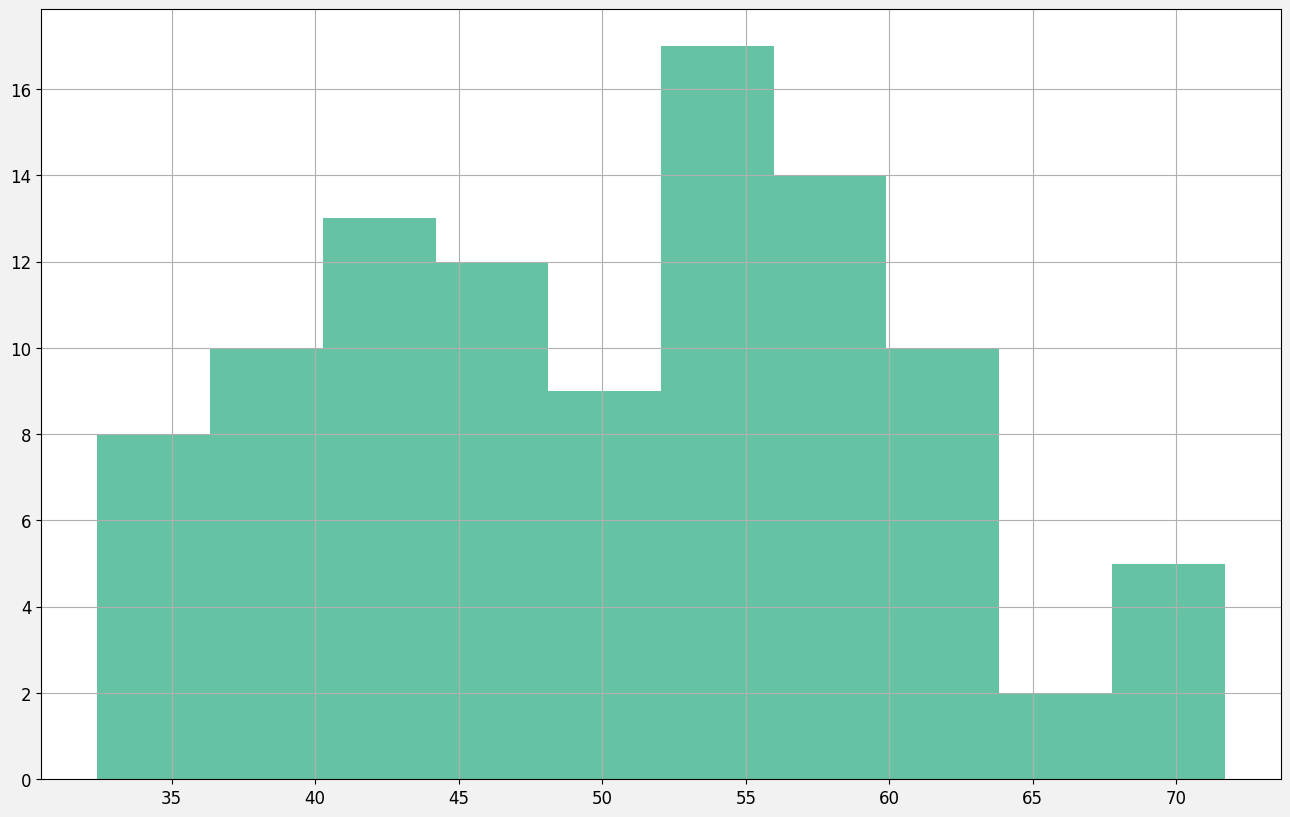

In [25]:
# Sampling simulated GDP per capita (expenditure side), normal distribution, mean: 50 000 USD, std: 10 000 USD
true_mean = 50
true_std = 10
num_countries = 100

rGDP = pd.Series(np.random.normal(true_mean, true_std, num_countries))

rGDP.hist()
plt.show()

In [26]:
mean_estimate = rGDP.mean()
print('Estimate of mean: ', mean_estimate)

Estimate of mean:  50.33747631766632


In [27]:
std_estimate = rGDP.std(ddof = 1)
print('Estimate of STD: ', std_estimate)

Estimate of STD:  9.734133621563663


### Standard error and estimating uncertainty

In [28]:
# Simulating many sets of draws to see variation:
N = 10000
sampleMeans = []

for i in range(N):
    sample = np.random.normal(true_mean, true_std, num_countries)
    sampleMeans.append(sample.mean())

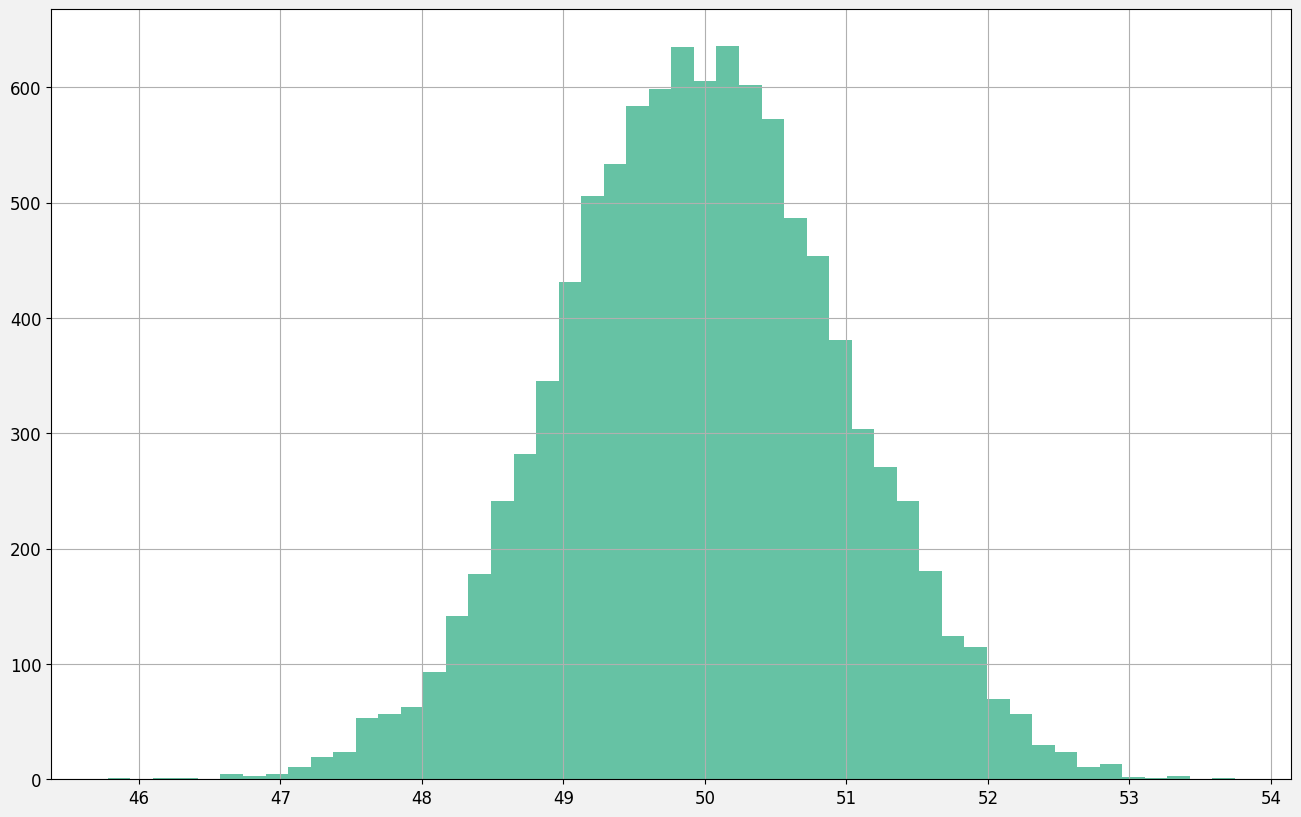

In [29]:
pd.Series(sampleMeans).hist(bins = 50)
plt.show()

In [30]:
# Getting the standard error (how uncertain is the sample estimate):
SE1 = pd.Series(sampleMeans).std()
print(SE1)

0.9960868614698123


In [31]:
# Finding standard error with the estimated mean and STD:
N = 10000
sampleMeans = []

for i in range(N):
    sample = np.random.normal(mean_estimate, std_estimate, num_countries)
    sampleMeans.append(sample.mean())

In [32]:
sampleMeans = pd.Series(sampleMeans)
SE2 = sampleMeans.std()
print(SE2)

0.9794136809343237


In [35]:
# Confidence interval one standard error (sample mean +/- one standard error):
CI_min = mean_estimate - 1 * SE2
CI_max = mean_estimate + 1 * SE2
print('Confidence interval between: ', CI_min, CI_max)

Confidence interval between:  49.358062636732 51.316889998600644


In [36]:
print(sampleMeans[(sampleMeans > CI_min) & (sampleMeans < CI_max)].count() / sampleMeans.count())

0.6786


In [37]:
# Confidence interval two standard errors (sample mean +/- two standard errors):
CI_min = mean_estimate - 2 * SE2
CI_max = mean_estimate + 2 * SE2
print('Confidence interval between: ', CI_min, CI_max)

Confidence interval between:  48.37864895579767 52.29630367953497


In [38]:
print(sampleMeans[(sampleMeans > CI_min) & (sampleMeans < CI_max)].count() / sampleMeans.count())

0.9561


In [39]:
CI_min = mean_estimate - 1.96 * SE2
CI_max = mean_estimate + 1.96 * SE2
print('Confidence interval between: ', CI_min, CI_max)
print(sampleMeans[(sampleMeans > CI_min) & (sampleMeans < CI_max)].count() / sampleMeans.count())

Confidence interval between:  48.41782550303505 52.2571271322976
0.9516


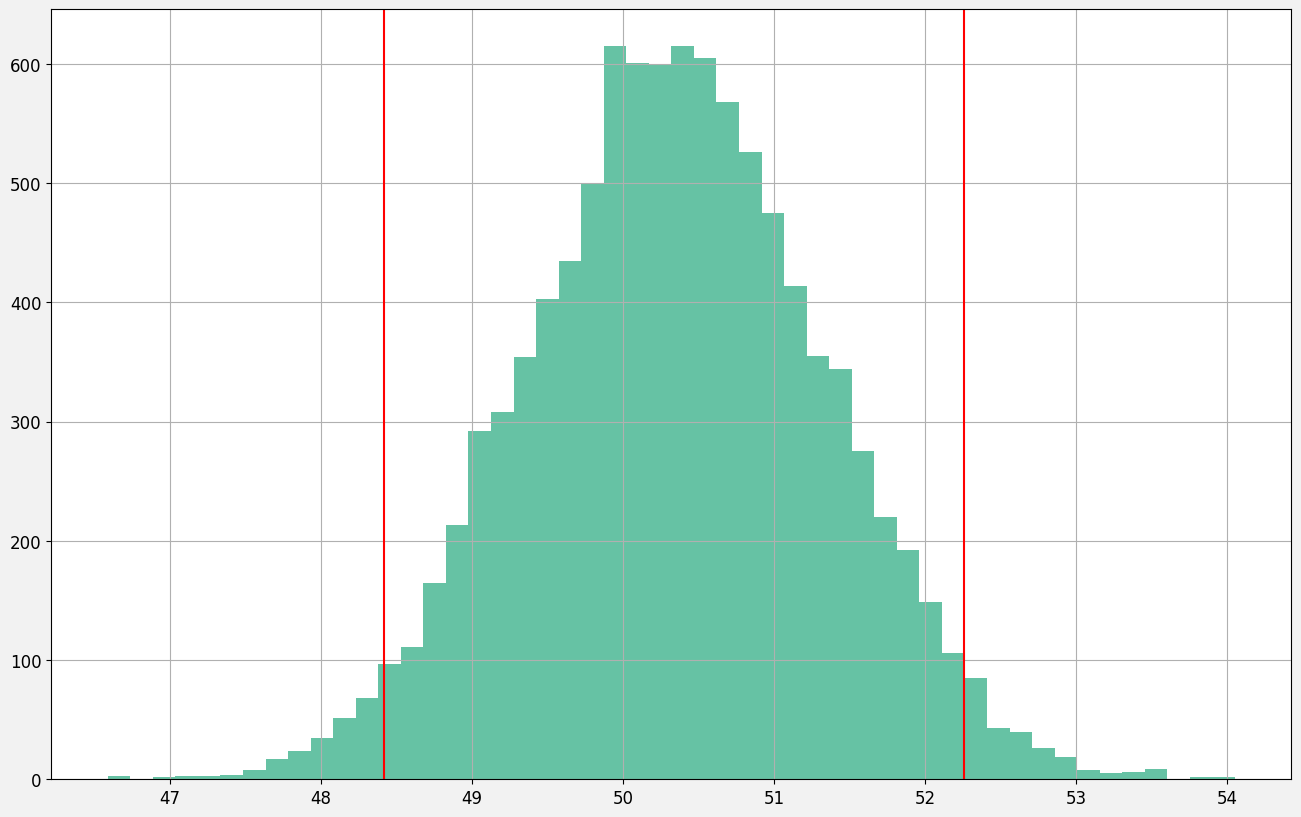

In [41]:
# Plotting the confidence interval:
fig, ax = plt.subplots()
sampleMeans.hist(bins = 50, ax = ax)
ax.axvline(CI_min, color = 'red')
ax.axvline(CI_max, color = 'red')
plt.show()

### Lazy statistician method

$SE_{mean} = \frac{\sigma}{\sqrt{S}}$

In [42]:
true_std / np.sqrt(num_countries)

1.0

$\hat{SE_{mean}} = \frac{\hat\sigma}{\sqrt{S}}$

In [44]:
SE_hat = std_estimate / np.sqrt(num_countries)
SE_hat

0.9734133621563663

In [47]:
CI_min = mean_estimate - 2 * SE_hat
CI_max = mean_estimate + 2 * SE_hat
print('95% confidence interval ', CI_min, CI_max)

95% confidence interval  48.39064959335359 52.28430304197906


### Bootstrapping

In [48]:
boot = rGDP.sample(n = 100, replace = True)

print(boot, rGDP)
print(boot.mean())

6     41.138361
49    43.179562
36    48.268944
52    58.301539
45    54.314719
        ...    
37    53.577390
89    54.525065
16    45.401071
77    56.995880
30    37.394589
Length: 100, dtype: float64 0     48.193382
1     63.258348
2     63.820999
3     47.606688
4     60.329370
        ...    
95    38.852878
96    39.323798
97    56.201231
98    49.118511
99    43.968862
Length: 100, dtype: float64
49.09565073699437


In [49]:
N = 10000
boots = []

for i in range(N):
    boot = rGDP.sample(n = 100, replace = True)
    boots.append(boot.mean())

boots = pd.Series(boots)

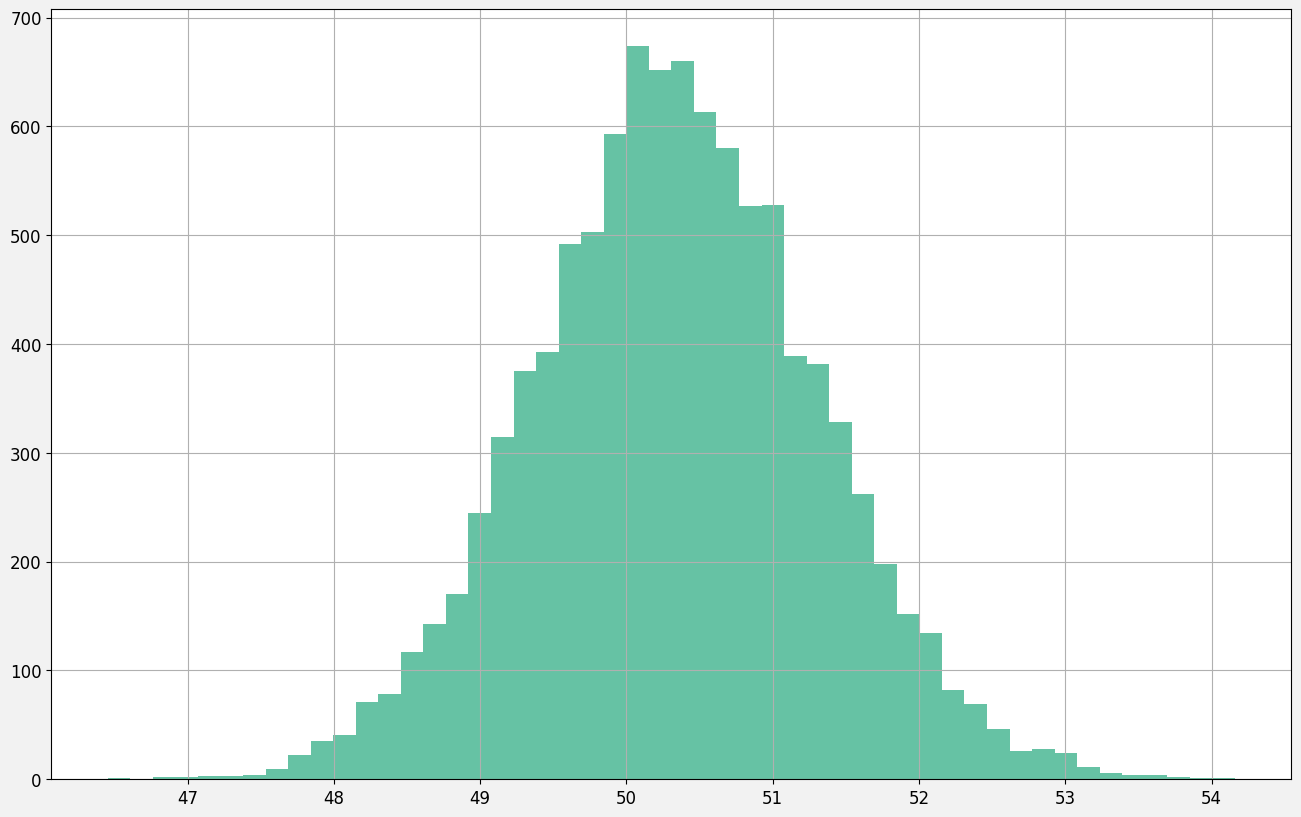

In [50]:
boots.hist(bins = 50)
plt.show()

In [51]:
# Estimating standard error of bootstrap:
SE_BS = boots.std()
SE_BS

0.969003101982584

### Uncertainty of other estimates

##### Proportion

In [65]:
p = .49
N = 1000

voteTrump = np.random.binomial(N, p)
voteTrump

491

In [66]:
p_hat = voteTrump / N
p_hat

0.491

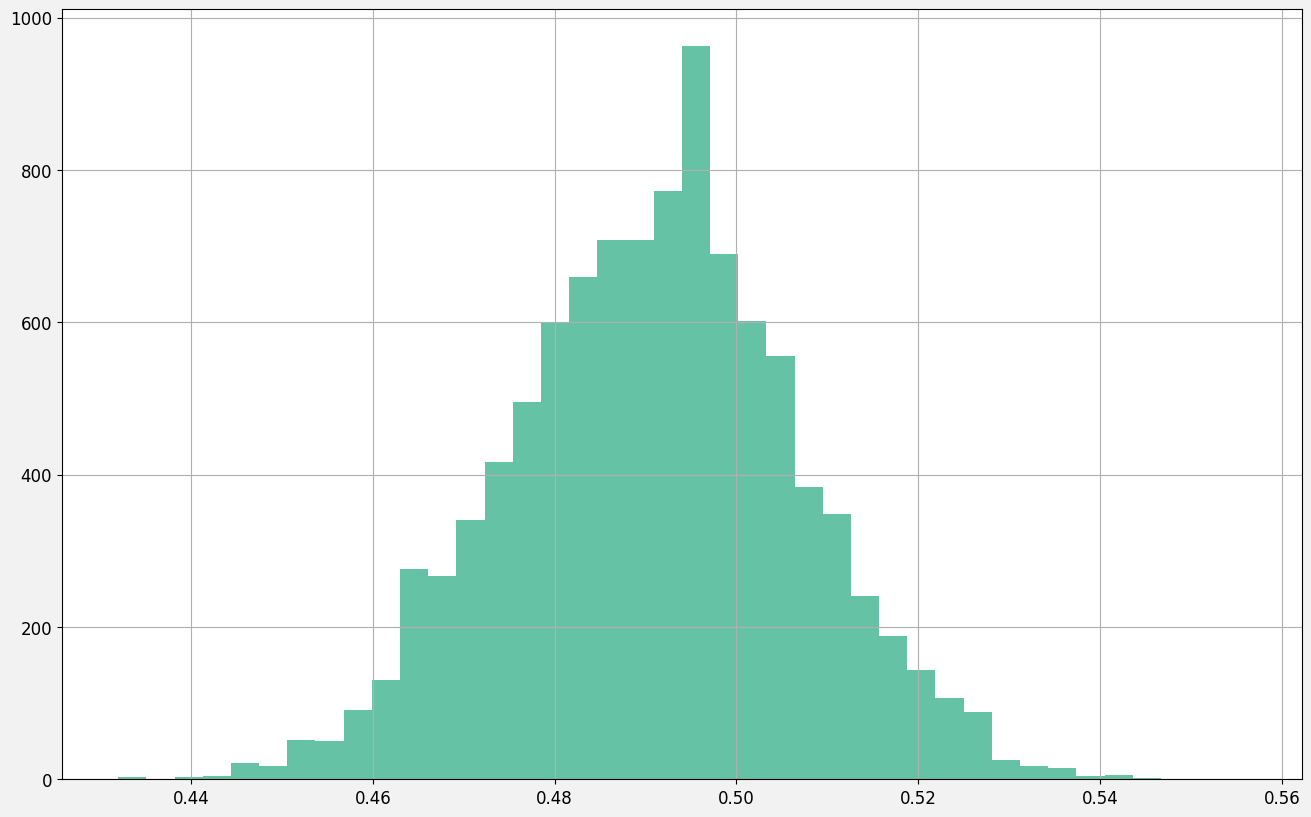

In [67]:
# Simulation to generate uncertainty:
props = []

for i in range(10000):
    prop = np.random.binomial(N, p_hat) / N
    props.append(prop)

props = pd.Series(props)

props.hist(bins = 40)
plt.show()

In [68]:
# Estimate standard error:
SE_prop = props.std()
SE_prop

0.015840931040176334

In [69]:
CI_min = p_hat - 2 * SE_prop
CI_max = p_hat + 2 * SE_prop
print('95% confidence interval: ', CI_min, CI_max)

95% confidence interval:  0.4593181379196473 0.5226818620803526


##### Lazy shortcut

For proportion of a binomial distribution, you can use: $SE = \sqrt{\frac{\hat{p}(1 - \hat{p})}{N}}$ to find the standard error.

In [70]:
SE2_prop = np.sqrt((p_hat*(1 - p_hat))/N)
SE2_prop

0.015808826648426505

In [71]:
CI_min = p_hat - 2 * SE2_prop
CI_max = p_hat + 2 * SE2_prop
print('95% confidence interval: ', CI_min, CI_max)

95% confidence interval:  0.459382346703147 0.522617653296853


### Standard error for a comparison

In [75]:
p_male = .57
p_female = .45
N_male = 400
N_female = 600

p_male_hat = np.random.binomial(N_male, p_male) / N_male
p_female_hat = np.random.binomial(N_female, p_female) / N_female

diff_hat = p_male_hat - p_female_hat

print('Sample male proportion: ', p_male_hat)
print('Sample female proportion: ', p_female_hat)

Sample male proportion:  0.6025
Sample female proportion:  0.44166666666666665


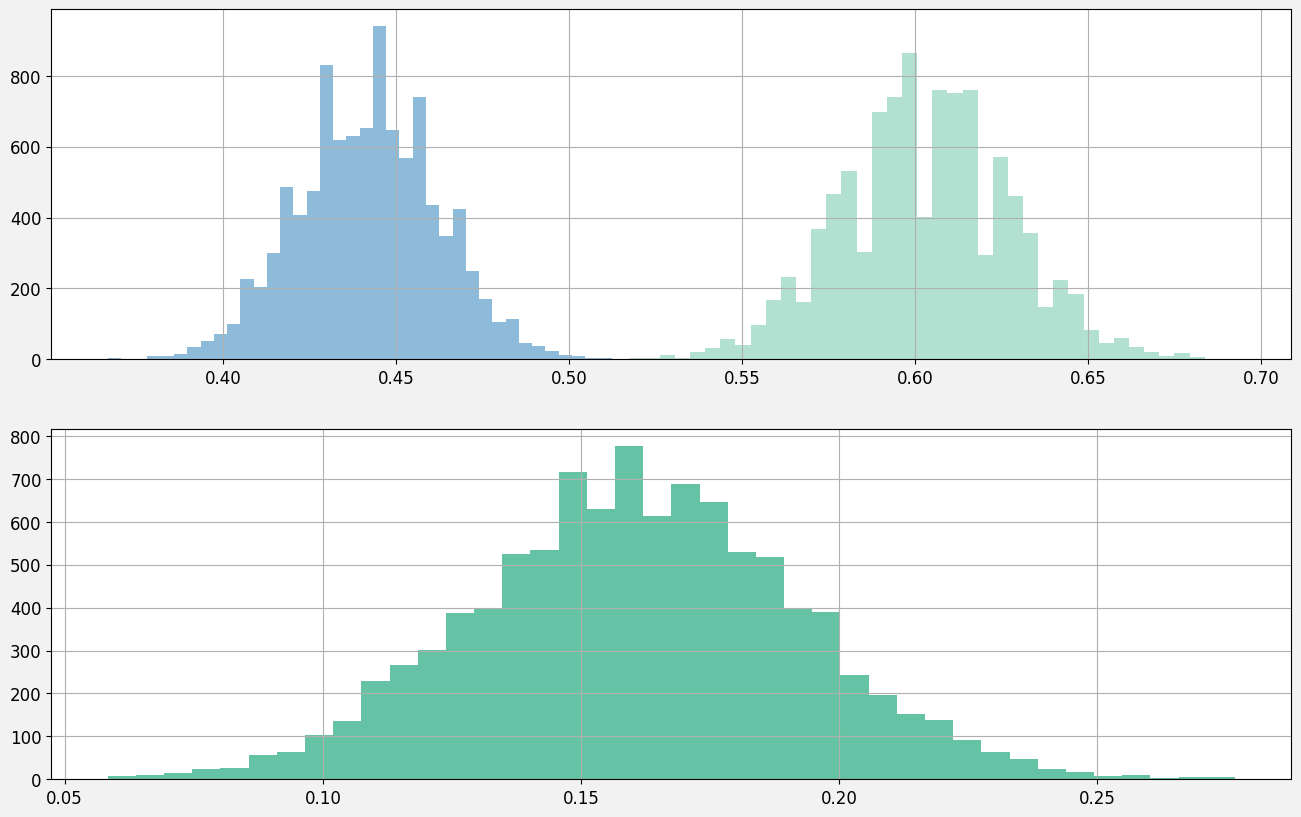

In [76]:
N_simulations = 10000

ps_male = []
ps_female = []

ps_male = pd.Series([np.random.binomial(N_male, p_male_hat) / N_male for i in range(N_simulations)])
ps_female = pd.Series([np.random.binomial(N_female, p_female_hat) / N_female for i in range(N_simulations)])

gender_gap = ps_male - ps_female

fig, ax = plt.subplots(2)
ps_male.hist(bins = 40, ax = ax[0], alpha = .5)
ps_female.hist(bins = 40, ax = ax[0], alpha = .5)
gender_gap.hist(bins = 40, ax = ax[1])
plt.show()

In [77]:
# Calculate estimate of standard error of the difference (gender_gap):
SE_diff = gender_gap.std()

CI_min = diff_hat - 2 * SE_diff
CI_max = diff_hat + 2 * SE_diff
print('SE of difference: ', SE_diff)
print('95% confidence interval: ', CI_min, CI_max)

SE of difference:  0.03163383523752895
95% confidence interval:  0.09756566285827549 0.22410100380839126


Alternatively: $SE_{diff} = \sqrt{SE_{male}^{2} + SE_{female}^{2}}$

In [79]:
# Using the formula like above for the standard error of proportions (under: Lazy shortcut):
SE2_male = np.sqrt((p_male_hat * (1 - p_male_hat)) / N_male)
SE2_female = np.sqrt((p_female_hat * (1 - p_female_hat)) / N_female)

# Then the alternate formula above:
SE2_diff = np.sqrt(SE2_male ** 2 + SE2_female ** 2)
print('SE of difference: ', SE2_diff)

# Confidence interval
CI_min = diff_hat - 2 * SE2_diff
CI_max = diff_hat + 2 * SE2_diff
print('95% confidence interval: ', CI_min, CI_max)

SE of difference:  0.03177624498537186
95% confidence interval:  0.09728084336258966 0.2243858233040771


### Uncertainty about uncertainty: distribution of standard deviations and $\chi^{2}$ distribution

In [97]:
true_mean = 0
true_std = 1
n = 10

y = np.random.normal(true_mean, true_std, n) # sample mean y_hat

In [99]:
y_bar = y.mean()
y_bar

-0.11910621959961158

Formula for standard deviation: $s_{y} = \sqrt{\frac{1}{n - 1} \sum_{i = 1}^{n}(y_{i} - \bar{y})^{2}}$

In [100]:
s_y = np.sqrt((1/(n - 1)) * np.sum((y - y_bar) ** 2))
s_y

0.9629834049344771

In [101]:
y.std(ddof = 1)

0.9629834049344771

In [102]:
def sstd(y):
    return np.sqrt((1/(n - 1)) * np.sum((y - y.mean()) ** 2))

In [103]:
nSims = 10000

sstd_dist = pd.Series([sstd(np.random.normal(y_bar, s_y, n)) for i in range(nSims)])

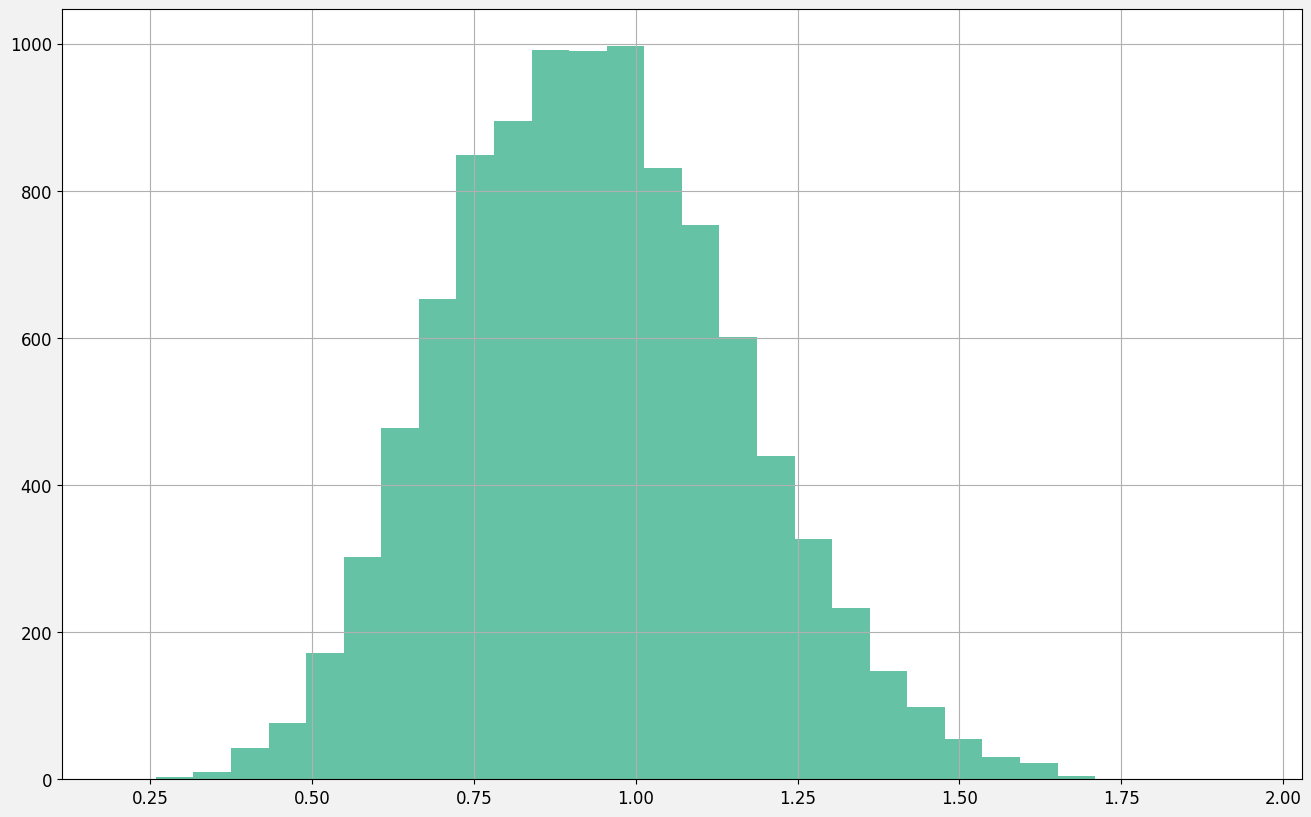

In [104]:
sstd_dist.hist(bins = 30)
plt.show()

If you perform the following transformation: $\frac{s_{y}^{2} \cdot (n - 1)}{\sigma^{2}}$, where $\sigma^{2}$ is the 'true' variance, then the observations will be distributed by what is called a $\chi^{2}$ (Chi-squared) distribution with $(n - 1)$ degrees of freedom:

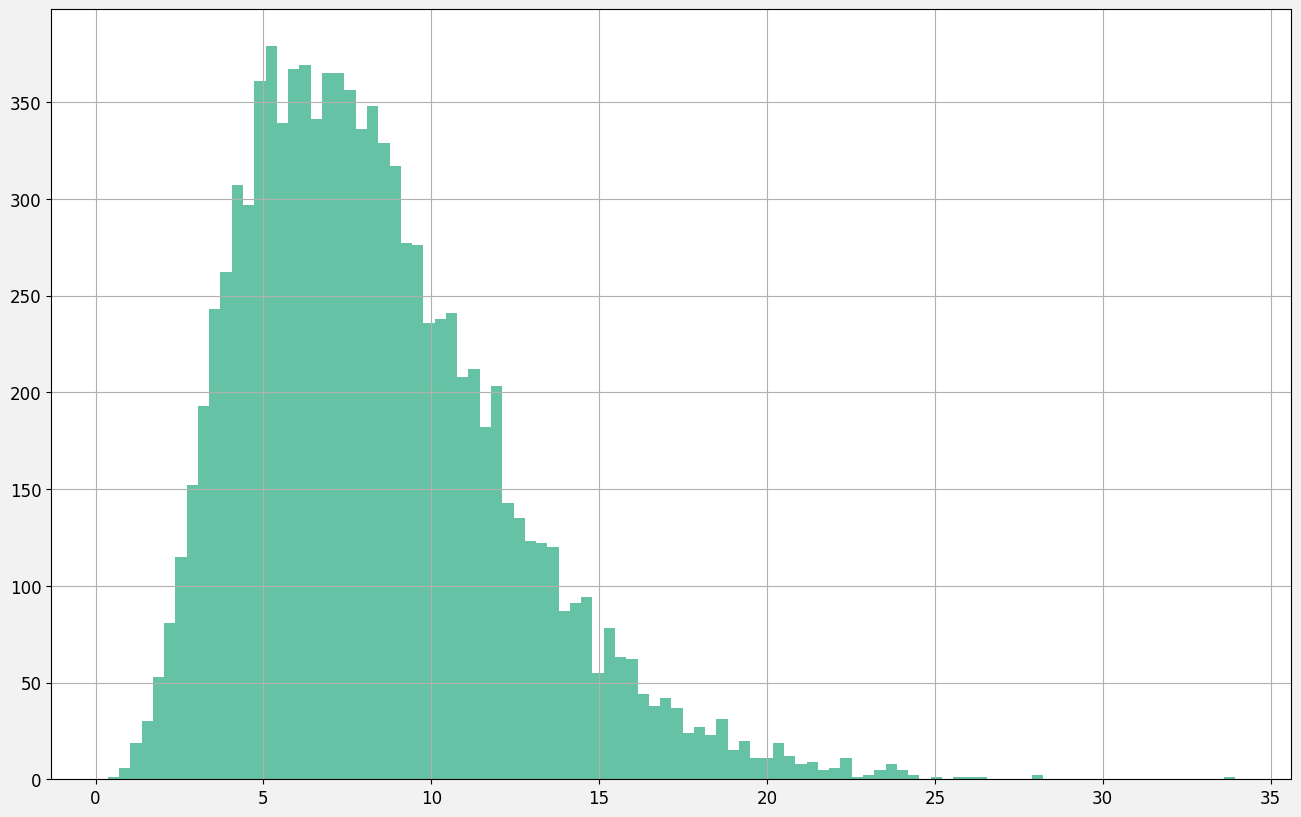

In [105]:
tr_sstd_dist = (sstd_dist ** 2 * (n - 1)) / (true_std ** 2)
tr_sstd_dist.hist(bins = 100)
plt.show()

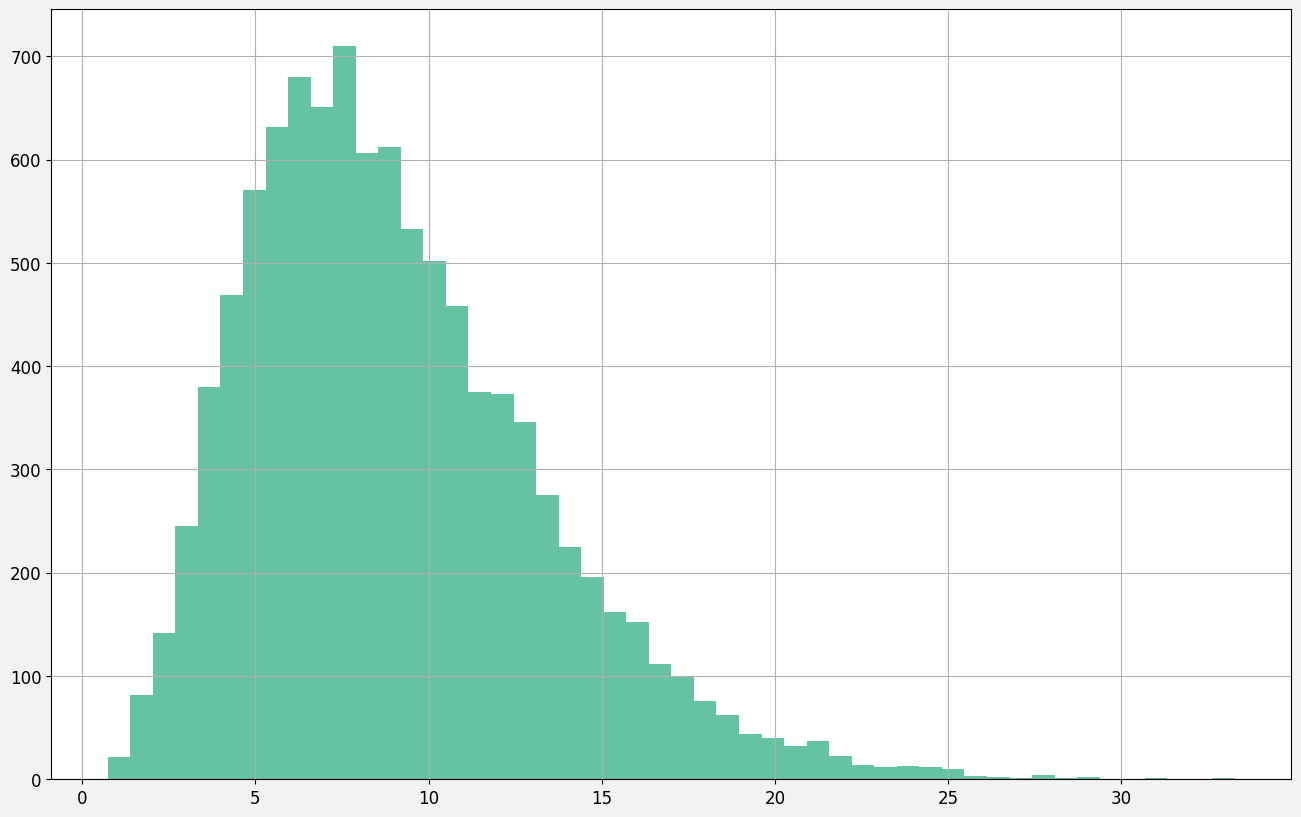

In [107]:
# We can generate random draws from a chi-squared distribution with numpy:
df = n - 1 # Degrees of freedom

chisqDraws = pd.Series(np.random.chisquare(df, 10000))
chisqDraws.hist(bins = 50)
plt.show()

### Degrees of freedom

Used to avoid overfitting the data. If we have one observation: x = 5, the mean is x = 5. The standard deviation is not possible to calculate with less that 2 obervations, we need to calculate the sample mean. To calculate the standard deviation we need at least 2 observations, giving us n - 1 => 2 - 1 = 1 degree of freedom.

### Fat tails and t-distribution

With small samples, there is more uncertainty than the normal distribution can take into account. This is where t-distributions comes in. 

In [113]:
n = 5
mySample = np.random.normal(30, 10, n)

In [114]:
s_mu = mySample.mean() # Sample mean
SE = mySample.std(ddof = 1) / np.sqrt(n)

# Remember spt == scipy.stats
t_025 = spt.t(df = n - 1).ppf(.975)
t_025

2.7764451051977987

In [115]:
CI_min = s_mu - SE * t_025
CI_max = s_mu + SE * t_025
print('Small-sample mean confidence interval: ', CI_min, CI_max)

Small-sample mean confidence interval:  16.60446877328716 34.757977263516615


### Bias

Look back at the formula for sample standard deviations: $s_{y} = \sqrt{\frac{1}{n - 1} \sum_{i = 1}^{n}(y_{i} - \bar{y})^{2}}$. The question is why we use $\frac{1}{n - 1}$ instead of $\frac{1}{n}$, let's try to understand by simulating:

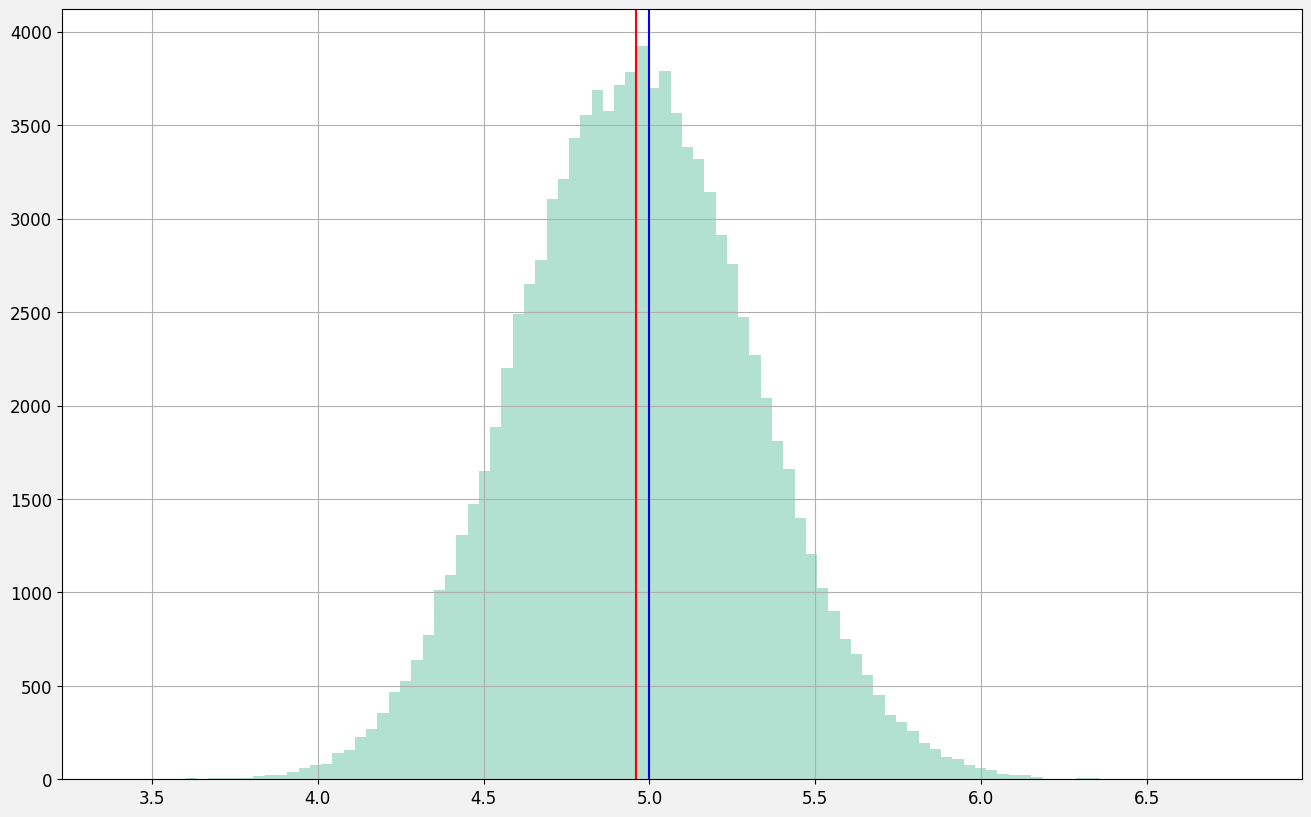

In [117]:
true_mean = 10
true_sd = 5
n = 100

nsim = 100000

sstds = pd.Series([np.random.normal(true_mean, true_sd, n).std() for i in range(nsim)])

simMeanSD = sstds.mean()

fig, ax = plt.subplots()
sstds.hist(bins = 100, alpha = .5)
ax.axvline(x = simMeanSD, color = 'red')
ax.axvline(x = true_sd, color = 'blue')
plt.show()

In the simulation, I simulated 100 000 sample standard deviations. The blur line represents the 'true' standard deviation from the actual normal distribution I was drawing from. The red line represents the mean of the simulated sample standard deviations. Notice the gap, this gap is the **statistical bias**. We have a sample estimate of the 'true' standard deviation that *on average* is not equal to the value we are trying to estimate. We want estimators where the average of the estimates would get closer to the 'true' value we are trying to estimate. So let's try with $\frac{1}{n - 1}$ to compare.

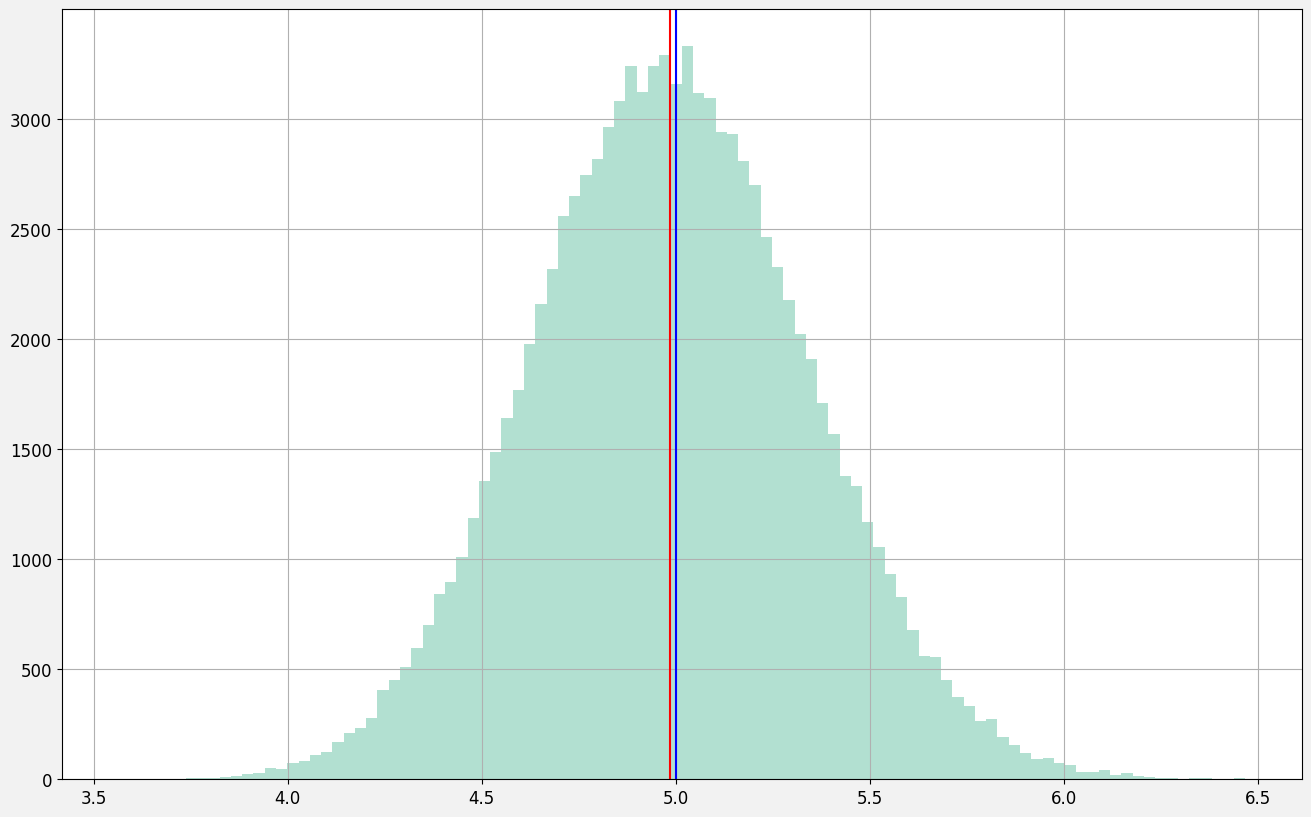

In [118]:
nsim = 100000

sstds = pd.Series([np.random.normal(true_mean, true_sd, n).std(ddof = 1) for i in range(nsim)])

simMeanSD = sstds.mean()

fig, ax = plt.subplots()
sstds.hist(bins = 100, alpha = .5)
ax.axvline(x = simMeanSD, color = 'red')
ax.axvline(x = true_sd, color = 'blue')
plt.show()

The gap is smaller, and will get smaller the larger the number of simulations are.

### Hypothesis testing, p-value and statistical significance

Starting with a null hypothesis and an alternative hypothesis. The null hypothesis is often the conservative hypothesiswe might like to show evidence against. 

In [119]:
theta_T = -4.3
theta_C = 0
sigma_T = 14
sigma_C = 7

n = 200

ys_T = np.random.normal(theta_T, sigma_T, n)
ys_C = np.random.normal(theta_C, sigma_C, n)

In [120]:
# Estimating sample means and sample standard deviations:
y_T_bar = ys_T.mean()
y_C_bar = ys_C.mean()
std_T = ys_T.std(ddof = 1)
std_C = ys_C.std(ddof = 1)

print(y_T_bar, std_T, y_C_bar, std_C)

-2.441050565848481 12.960340023399395 0.520549584171605 7.178432338769482


The estimate we are interested in: $\hat{\theta} = \bar{y_{T}} - \bar{y_{C}}$

In [121]:
theta_hat = y_T_bar - y_C_bar
theta_hat

-2.961600150020086

In [122]:
# The standard error is calculated:
SE_theta = np.sqrt((std_T ** 2) / (n) + (std_C ** 2) / (n))
SE_theta

1.0476170683136556

In [123]:
CI_min = theta_hat - 2 * SE_theta
CI_max = theta_hat + 2 * SE_theta
print('95% confidence interval: ', CI_min, CI_max)

95% confidence interval:  -5.056834286647398 -0.8663660133927746


##### Statistical signifigance

##### p-value

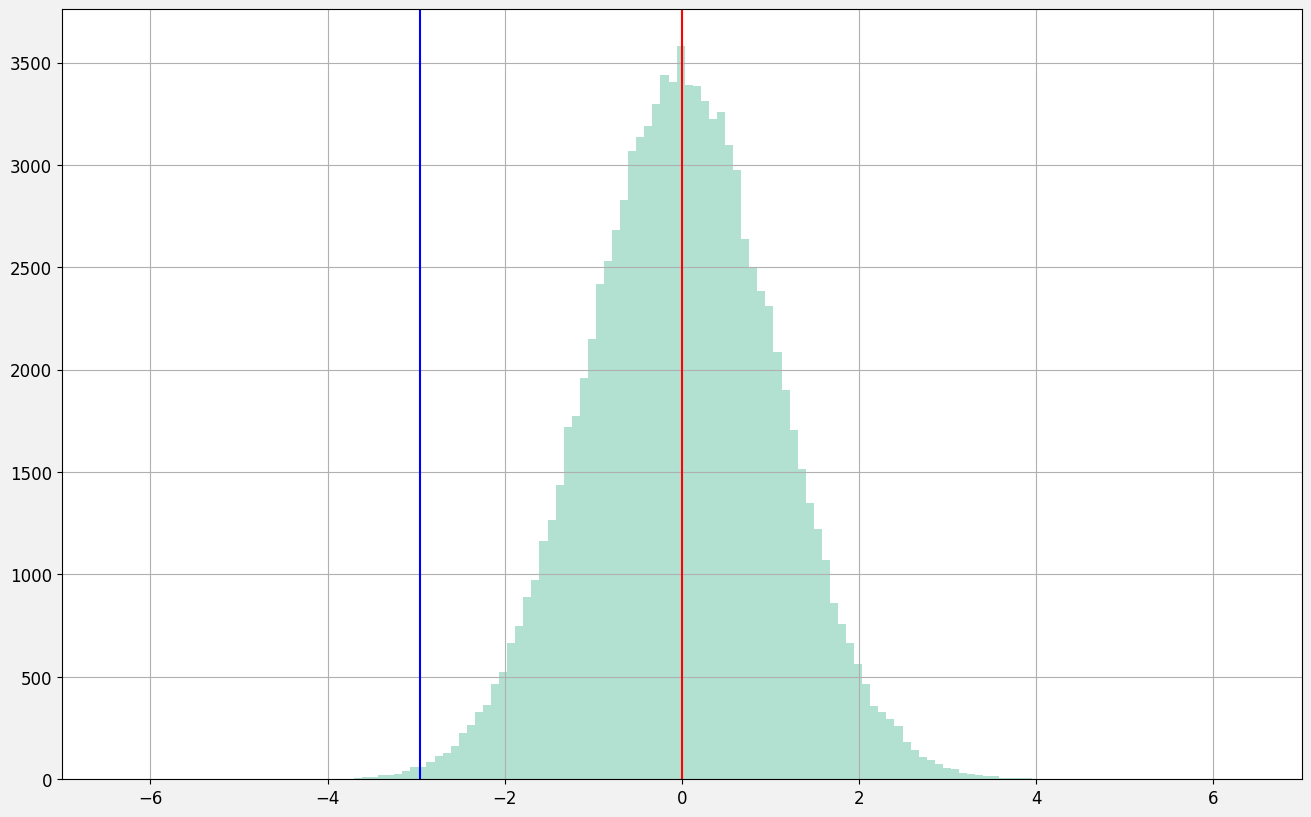

In [125]:
# Simulate a distribution assuming that our null hypothesis is true
nsims = 100000
null_dist = pd.Series(np.random.normal(0, SE_theta, nsims))

fig, ax = plt.subplots()
null_dist.hist(bins = 100, alpha = .5, ax = ax)
ax.axvline(x = 0, color = 'red')
ax.axvline(x = theta_hat, color = 'blue')
ax.set_xlim(-7, 7)
plt.show()

The red line is the null hypothesis of 0 change, and the blue line is the actual test statistic. What is the chance, according to our simulated distribution that we get a test statistic equal to or greater than our actual test statistic by pure chance, assuming the null hypothesis is true? We can calculate this:

In [126]:
null_dist[null_dist < theta_hat].count() / nsims

0.00211

This is the p-value. If we are using a 5% signifigance level, as long as the p-value < .05, then we would say that our test statistic is significant. We could also use the cumulative distribution function from scipy.stats:

In [127]:
spt.norm(0, SE_theta).cdf(theta_hat)

0.0023494095504491964